# Eurostat vs. Wikidata Entity Coverage Analysis

This notebook fetches official Eurostat statistics and compares them with the entity counts extracted from Wikidata.

**Eurostat sources:**
- **Secondary Education** (`educ_uoe_enrs04` & `educ_uoe_enrs01`): Students enrolled, ISCED levels 2-3
- **Primary Education** (`educ_uoe_enrp04`): Students enrolled, ISCED level 1
- **Hospital Beds** (`hlth_rs_bds1`): Available beds in hospitals (HP.1), Total
- **LAU (Local Administrative Units)**: Count per country from Eurostat Excel file

**Wikidata sources:** Extracted hierarchy CSV files (see `orgpackage/dataprocesser.py`)

In [44]:
import requests
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
print('Libraries loaded.')

Libraries loaded.


## 1. Data Loading

We load the comparison dataset previously generated from Eurostat and Wikidata.

In [45]:
df = pd.read_csv('./data/eurostat_wikidata_comparison.csv')
display(df.head())

,Country,ISO,Eurostat_Primary_Students,Eurostat_Secondary_Students,Eurostat_Hospital_Beds,Eurostat_LAU_Count,Wikidata_Primary_Schools,Wikidata_Secondary_Schools,Wikidata_Hospitals,Wikidata_Local_Governments,Beds_per_Hospital,Students_per_School,Hospital_Coverage_%,School_Coverage_%,LocalGov_Coverage_%,LocalGov_Coverage,Hospital_Coverage,PrimarySchool_Coverage,SecondarySchool_Coverage
0,Spain,ES,2832554.0,3710315.0,146310.0,8132,3025,1361,1122,8623,130.401070,1491.762198,280.161666,69.772073,106.037875,106.037875,280.161666,61.873458,75.295718
1,Portugal,PT,606399.0,737930.0,35635.0,3092,56,57,189,32,188.544974,11896.716814,193.764809,8.748913,1.034929,1.034929,193.764809,5.350406,15.855598
2,France,FR,4126149.0,6271611.0,429674.0,34936,110,603,1030,83893,417.159223,14583.113604,87.576587,7.137251,240.133387,240.133387,87.576587,1.544561,19.736091
3,Malta,MT,27537.0,33141.0,1993.0,68,0,2,14,0,142.357143,30339.000000,256.631877,3.430678,0.000000,0.000000,256.631877,0.000000,12.387604
4,Greece,EL,578574.0,687813.0,54704.0,6142,10,15,176,2,310.818182,50655.480000,117.539394,2.054730,0.032563,0.032563,117.539394,1.001379,4.476554


## 2. Estimation of Global Means (Ratios)

We calculate separate global benchmarks for Primary schools, Secondary schools, and Hospitals to estimate coverage more accurately.

In [46]:
# Overall Means for Benchmarking
total_beds = df['Eurostat_Hospital_Beds'].sum()
total_wd_hospitals = df['Wikidata_Hospitals'].sum()
global_mean_beds = 150

total_p_students = df['Eurostat_Primary_Students'].sum()
total_wd_p_schools = df['Wikidata_Primary_Schools'].sum()
global_mean_p_students = 300

total_s_students = df['Eurostat_Secondary_Students'].sum()
total_wd_s_schools = df['Wikidata_Secondary_Schools'].sum()
global_mean_s_students = 300

print(f'benchmarks (Global Mean Size):')
print(f'  - Hospital Beds per Hospital: {global_mean_beds:.1f}')
print(f'  - Primary Students per School: {global_mean_p_students:.1f}')
print(f'  - Secondary Students per School: {global_mean_s_students:.1f}')

benchmarks (Global Mean Size):
  - Hospital Beds per Hospital: 150.0
  - Primary Students per School: 300.0
  - Secondary Students per School: 300.0


## 3. Coverage Analysis

We calculate the coverage for four distinct classes:
1. **Local Government**: Wikidata / Eurostat LAU
2. **Hospitals**: Wikidata / (Beds / Global Mean)
3. **Primary Schools**: Wikidata / (Students / Global Mean)
4. **Secondary Schools**: Wikidata / (Students / Global Mean)

In [47]:
# Calculate Coverage % for each class
df['LocalGov_Coverage'] = (df['Wikidata_Local_Governments'] / df['Eurostat_LAU_Count']) * 100
df['Hospital_Coverage'] = (df['Wikidata_Hospitals'] / (df['Eurostat_Hospital_Beds'] / global_mean_beds)) * 100
df['Primary_Coverage'] = (df['Wikidata_Primary_Schools'] / (df['Eurostat_Primary_Students'] / global_mean_p_students)) * 100
df['Secondary_Coverage'] = (df['Wikidata_Secondary_Schools'] / (df['Eurostat_Secondary_Students'] / global_mean_s_students)) * 100

cols_to_plot = ['LocalGov_Coverage', 'Hospital_Coverage', 'Primary_Coverage', 'Secondary_Coverage']
display(df[['Country'] + cols_to_plot].sort_values('Hospital_Coverage', ascending=False))

,Country,LocalGov_Coverage,Hospital_Coverage,Primary_Coverage,Secondary_Coverage
25,Ireland,48.192771,160.383985,1.360682,13.822896
0,Spain,106.037875,115.029731,32.038224,11.004456
3,Malta,0.000000,105.368791,0.000000,1.810446
24,Denmark,54.545455,103.448276,123.196017,116.462348
9,Sweden,54.482759,97.497373,150.794269,36.927001
8,Netherlands,485.672515,88.779072,171.099242,2.786657
10,Finland,294.822006,88.526064,44.235623,46.765437
19,Slovenia,7.075472,84.673554,105.295875,18.310370
1,Portugal,1.034929,79.556616,2.770453,2.317293
26,Luxembourg,31.000000,71.664829,2.092050,21.799076


## 4. Visualization

We use a clustered bar chart and a green-scale heatmap to visualize the coverage gaps.

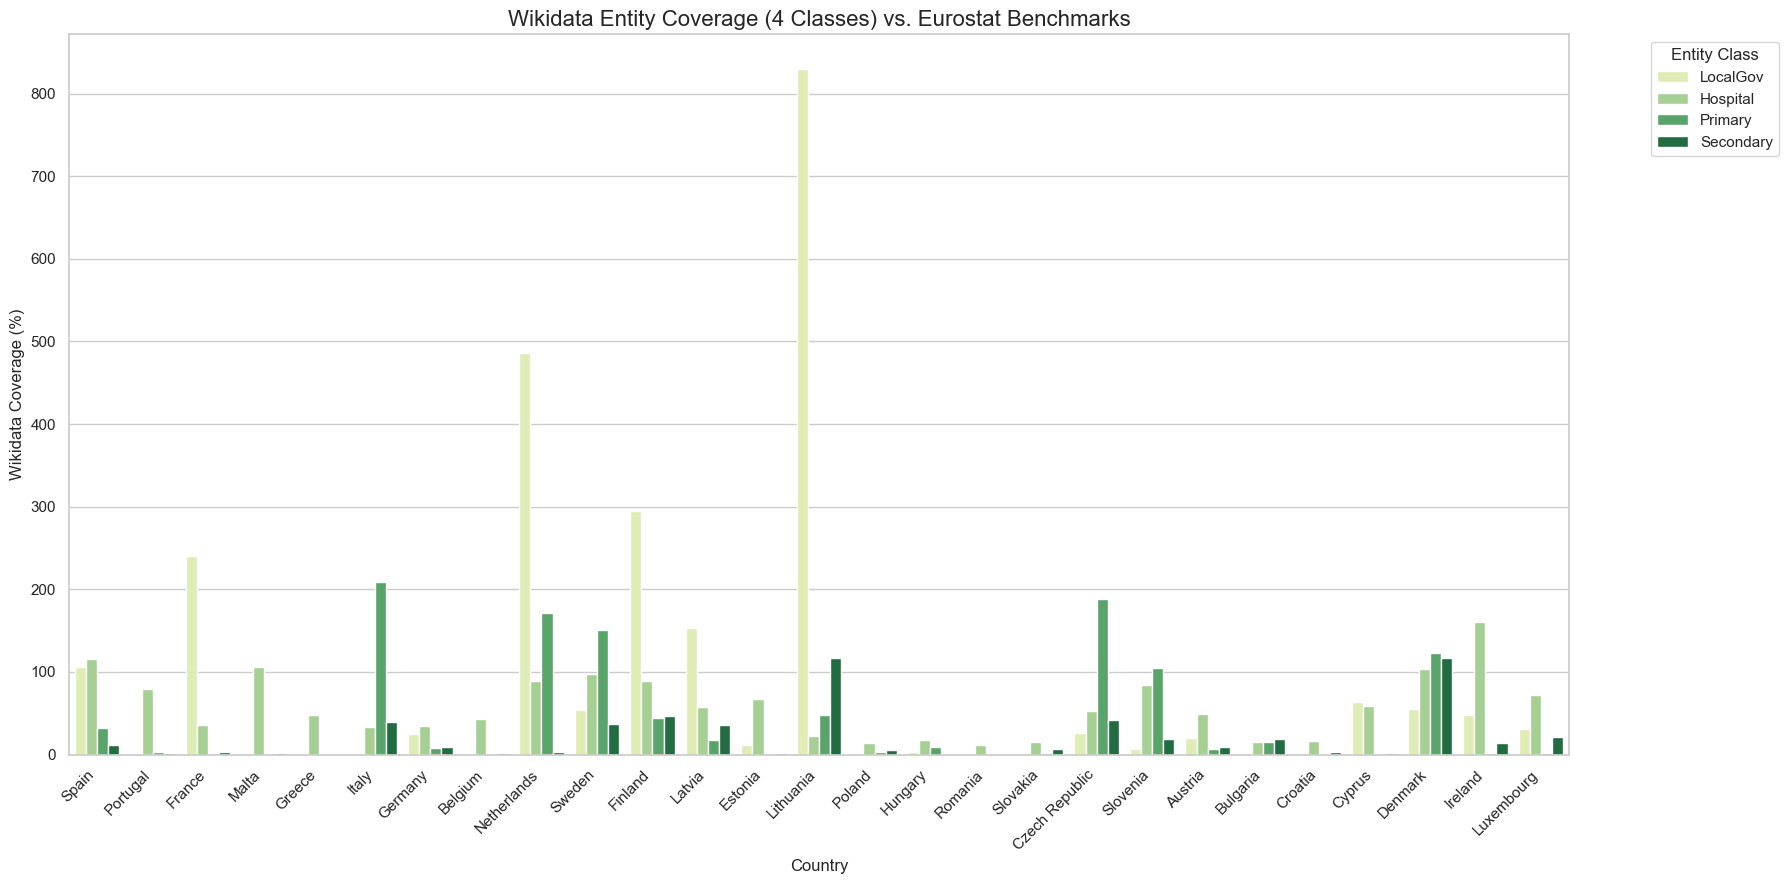

In [48]:
# Melt for clustered bar plotting
plot_df = df.melt(id_vars=['Country'], value_vars=cols_to_plot, var_name='Class', value_name='Coverage_Percent')
plot_df['Class'] = plot_df['Class'].str.replace('_Coverage', '')

plt.figure(figsize=(18, 9))
ax = sns.barplot(data=plot_df, x='Country', y='Coverage_Percent', hue='Class', palette='YlGn')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Wikidata Coverage (%)')
plt.title('Wikidata Entity Coverage (4 Classes) vs. Eurostat Benchmarks', fontsize=16)
plt.legend(title='Entity Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Coverage Heatmap (0-100% Scale)

Darker green indicates higher coverage relative to the benchmarks.

SyntaxError: invalid syntax (838631464.py, line 1)

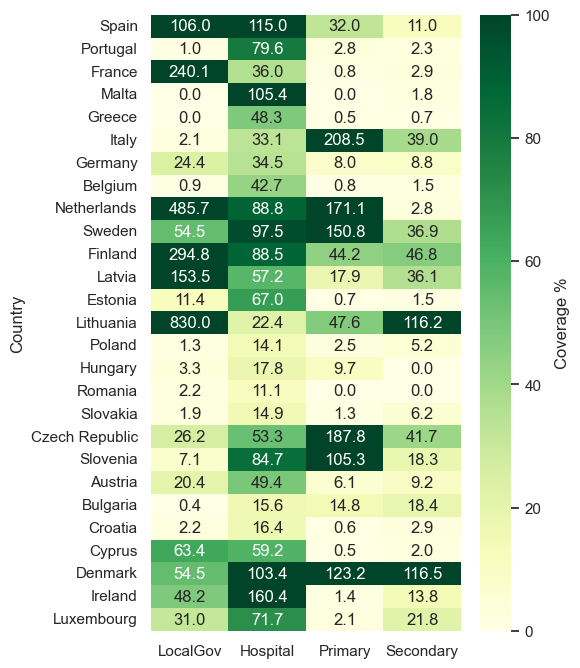

In [50]:
heatmap_data = df.set_index('Country')[cols_to_plot]
heatmap_data.columns = [c.replace('_Coverage', '') for c in heatmap_data.columns]

plt.figure(figsize=(5, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGn", vmin=0, vmax=100, cbar_kws={'label': 'Coverage %'})
plt.show()

In [40]:

# Print the mean coverage per class
print(heatmap_data.clip(upper=100).mean())

LocalGov     35.421694
Hospital     73.204302
Primary      29.426856
Secondary    19.678536
dtype: float64
